# Calculate Sternberg model tuning -- to load, and to stimulus identity

Changing to delay=150

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-06-09 11:57:35.759668: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 11:57:35.767687: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-09 11:57:35.776225: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-09 11:57:35.778842: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-09 11:57:35.785895: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# the 11 models with > 0.7 accuracy are:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [4]:
# find folder names within model directory

perfs = []
for i, model_name in enumerate(model_names):
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
    load1_idx = np.where(trial_labels[:,0] == 1)[0]
    load2_idx = np.where(trial_labels[:,0] == 2)[0]
    load3_idx = np.where(trial_labels[:,0] == 3)[0]
    perfs.append([np.mean(trial_perfs[load1_idx]), np.mean(trial_perfs[load2_idx]), np.mean(trial_perfs[load3_idx])])
    print(f'Model {model_name}, performance: {perfs[i]}')


Model Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901, performance: [0.96, 0.85, 0.76]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721, performance: [0.89, 0.73, 0.7]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000, performance: [0.97, 0.84, 0.75]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152, performance: [0.9, 0.92, 0.81]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002, performance: [0.96, 0.78, 0.7]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744, performance: [0.96, 0.86, 0.73]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239, performance: [0.97, 0.83, 0.72]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128, performance: [0.95, 0.83, 0.79]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128, performance: [0.95, 0.83, 0.74]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647, performance: [0.82, 0.79, 0.7]
Model Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131, performance: [0.99, 0.8, 0.71]


## Load-selectivity

### all models

Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...


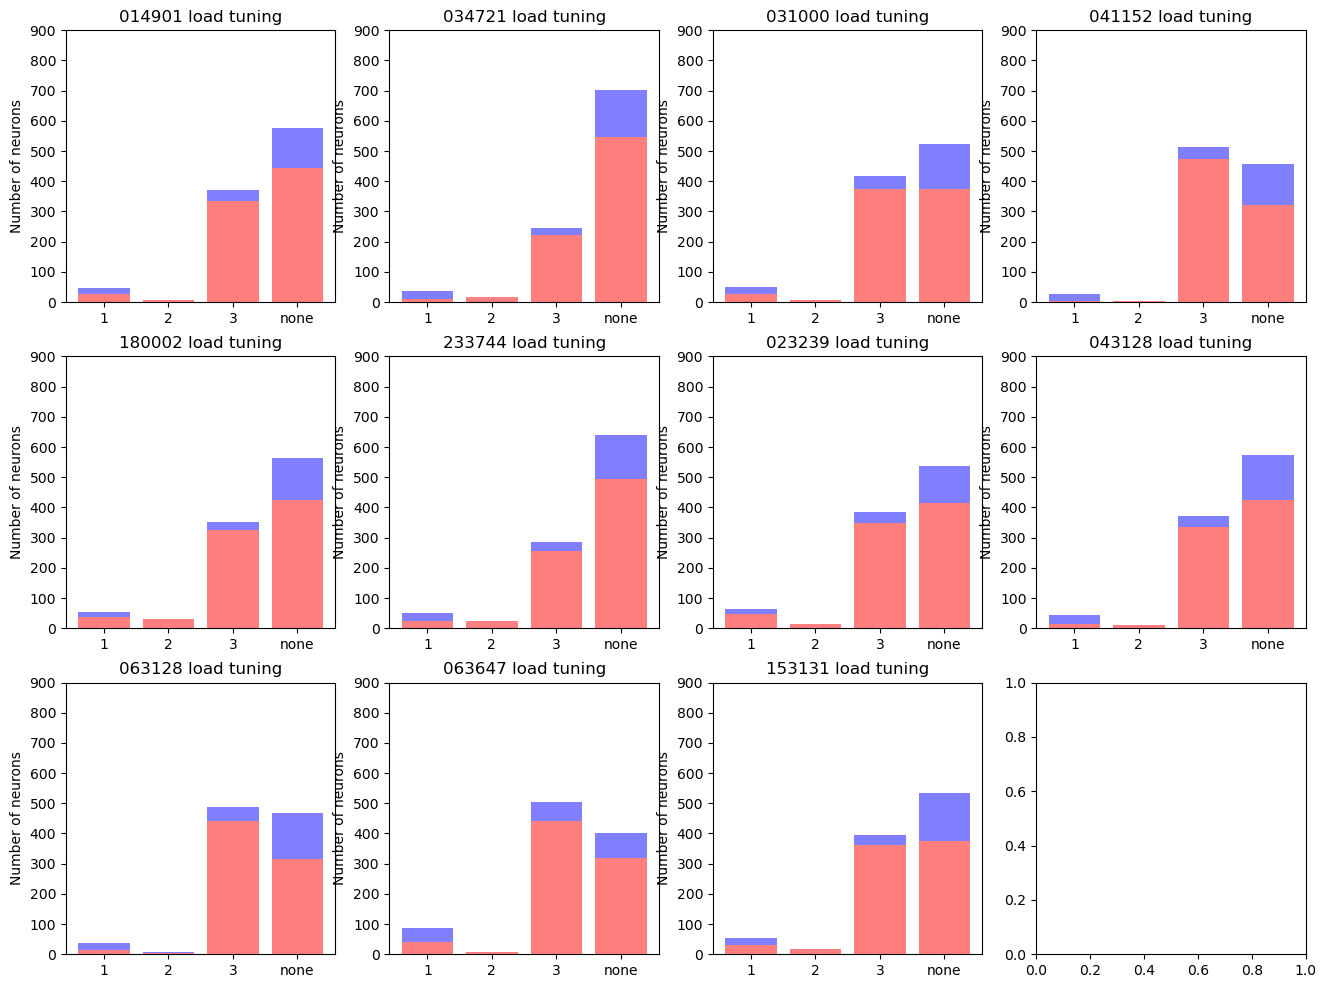

In [9]:
importlib.reload(rn)

fig, axs = plt.subplots(3, 4, figsize=(16,12))
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    rn.plot_load_tuning(tuning, tuning_options = [1, 2, 3, np.nan], exc_ind=exc_ind, title=f'{model_name[-6:]} load tuning', ax=axs[i])
    axs[i].set_xlabel('')
    axs[i].set_ylim([0, 900])

## Stim-selectivity

nonparametric version

### multiple models

In [ ]:
importlib.reload(rn)

for i, model_name in enumerate(model_names):
    
    model_dir = os.path.join(all_models_dir, model_name)
    save_path = os.path.join(model_dir, 'stim1_tuning_nonparametric.npz')
    if os.path.exists(save_path):
        print(f'Tuning file already exists for {model_name}, skipping...')
        continue
    
    # neural data
    _, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                                all_models_dir = all_models_dir, load_LFP=False)
    _, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                                all_models_dir = all_models_dir, load_LFP=False)
    rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0) # concatenate
    
    settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, 
                                        other_labels="balance_stim",
                                        all_models_dir=all_models_dir)

    # behavioral data
    trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_match",
                                                        all_models_dir=all_models_dir)
    trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_stim",
                                                        all_models_dir=all_models_dir)
    trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)
    trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)
    trial_outputs = np.concatenate((trial_outputs_match, trial_outputs_stim), axis=0)

    # turn all inf into nans
    trial_labels = np.nan_to_num(trial_labels, nan=np.inf)
    trial_perfs = np.nan_to_num(trial_perfs, nan=np.inf)
    trial_outputs = np.nan_to_num(trial_outputs, nan=np.inf)
    
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    bhv_vars = {'trial_labels': trial_labels, 'trial_perfs': trial_perfs, 'trial_outputs': trial_outputs}
    tuning = rn.calc_stim1_tuning_nonparametric(model_name, condn_phrase, condn_num, other_labels = "balance_match",
                        rates_data=rates_data, other_variables=bhv_vars,
                        kw_alpha=0.05, dunn_alpha=0.05, dunn_p_adjust='holm',
                        use_prescreen=True, prescreen_alpha=0.20,
                        show_progress=True, all_models_dir=all_models_dir)

    rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name} stimulus 1 tuning', ax=None)

    # save tuning to the model folder as stim1_tuning.npz
    np.savez(save_path, stim1_tuning=tuning)

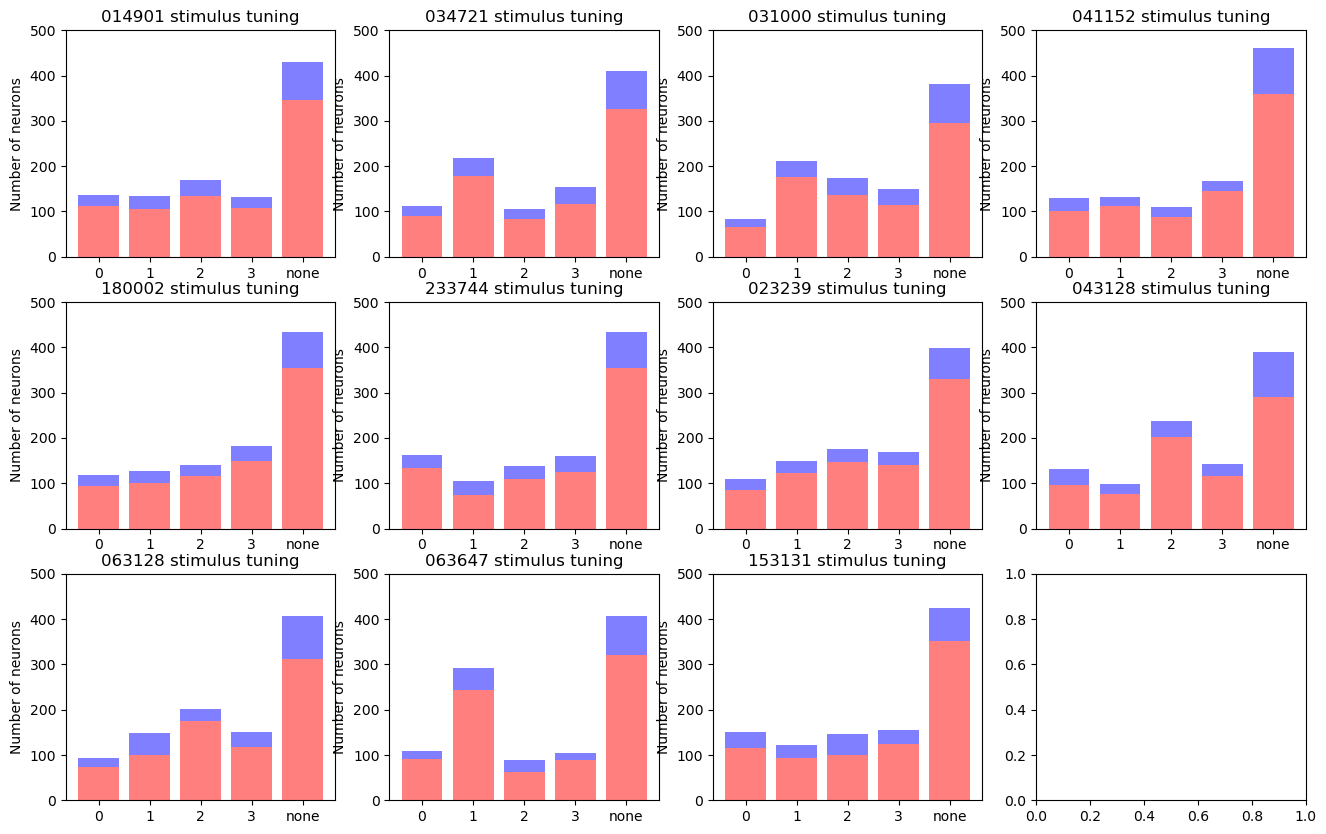

In [13]:
# make single plot of all parametric, and all nonparametric. subplot for each model

# tuning_names = ['stim1_tuning.npz', 'stim1_tuning_nonparametric.npz']
# label_name = ['parametric', 'nonparametric']

tuning_names = ['stim1_tuning_nonparametric.npz']
label_name = ['nonparametric']

for i, tuning_name in enumerate(tuning_names):
    fig, ax = plt.subplots(3, 4, figsize=(16,10))
    ax = ax.flatten()
    for j, model_name in enumerate(model_names):
        model_dir = os.path.join(all_models_dir, model_name)
        save_path = os.path.join(model_dir, tuning_name)
        tuning = np.load(save_path)['stim1_tuning']
        exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
        
        rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name[-6:]} stimulus tuning', ax=ax[j])
        ax[j].set_ylim([0, 500])
        ax[j].set_xlabel('')
        
plt.show()
    

## Load & Stim selectivity together

### load-selective within stim1-selection

Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...


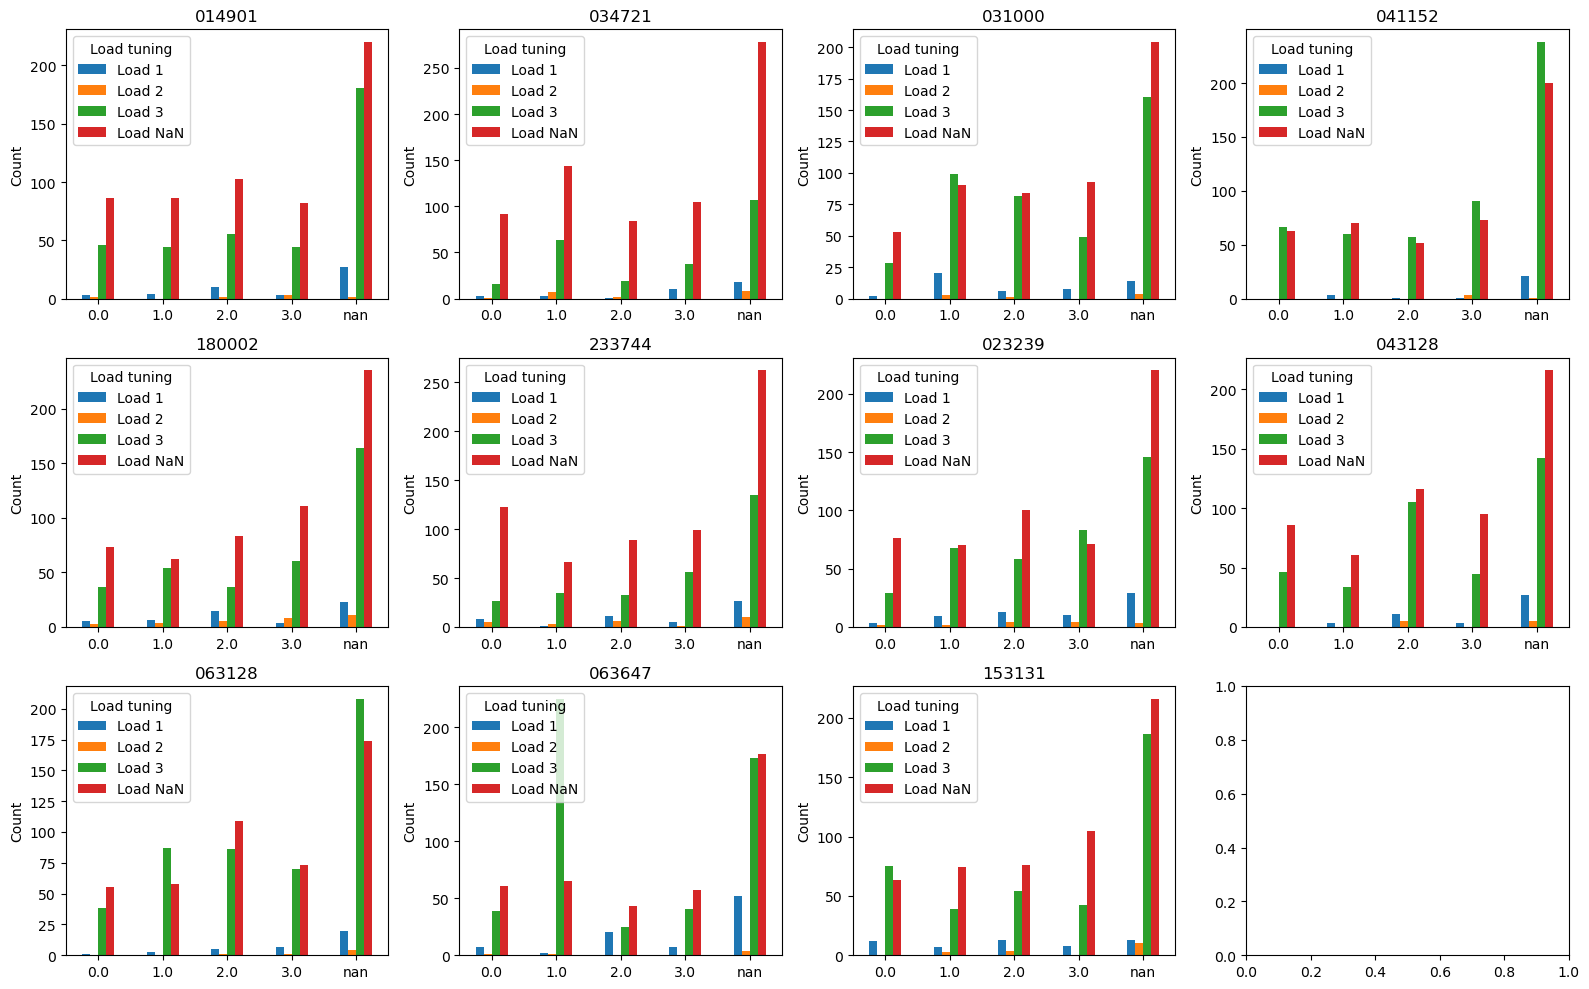

In [17]:
# all models

import pandas as pd

fig, ax = plt.subplots(3, 4, figsize=(16,10))
ax = ax.flatten()
for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)

    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels= "balance_stims",
                                all_models_dir=all_models_dir)

    stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']

    # build database for each neuron and its tuning
    neuron_db = []
    for neuron_idx in range(load_tuning.shape[0]):
        neuron_info = {'load_tuning': load_tuning[neuron_idx],
                    'stim1_tuning': stim1_tuning[neuron_idx]}
        neuron_db.append(neuron_info)
        
    neuron_db = pd.DataFrame(neuron_db)
    neuron_db['tuning_combination'] = neuron_db.apply(lambda row: f"load{row['load_tuning']}_stim{row['stim1_tuning']}", axis=1)
    tuning_counts = neuron_db['tuning_combination'].value_counts()

    # Recreate counts as a DataFrame
    df_counts = tuning_counts.rename_axis('combination').reset_index(name='count')

    # Extract load and stim values from strings
    df_counts[['load', 'stim']] = df_counts['combination'].str.extract(r'load(.*?)_stim(.*)')

    # Convert to numeric (keep NaN properly)
    df_counts['load'] = pd.to_numeric(df_counts['load'], errors='coerce')
    df_counts['stim'] = pd.to_numeric(df_counts['stim'], errors='coerce')

    # Pivot so rows = stim, columns = load
    pivot = df_counts.pivot(index='stim', columns='load', values='count')

    # Reindex to enforce order
    pivot = pivot.reindex(index=[0,1,2,3,np.nan], columns=[1,2,3,np.nan])

    # Plot
    pivot.plot(kind='bar', ax=ax[i])

    # ax[i].set_xlabel('Stim1 tuning')
    ax[i].set_ylabel('Count')
    ax[i].set_xlabel('')
    ax[i].set_title(f'{model_name[-6:]}')
    ax[i].legend(title='Load tuning', labels=['Load 1', 'Load 2', 'Load 3', 'Load NaN'])
    # turn tick labels into flat orietation
    ax[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()